# **Waze Churn Analysis Project**

*** The Business Scenario ***

The leadership team wants to **build a machine learning model to predict user churn** in the Waze app. To get the best results, your team decides to build and test two tree-based models: random forest and XGBoost.

Your work will help leadership make informed business decisions to prevent user churn, improve user retention, and grow Waze’s business.


**Build a machine learning model**

**The purpose** of this model is to find factors that drive user churn.

**The goal** of this model is to predict whether or not a Waze user is retained or churned.
<br/>

**Part 1:** Ethical considerations
* Consider the ethical implications of the request

* Should the objective of the model be adjusted?

**Part 2:** Feature engineering

* Perform feature selection, extraction, and transformation to prepare the data for modeling

**Part 3:** Modeling

* Build the models, evaluate them, and advise on next steps



# **Build a machine learning model**


** Plan **

1. Predict user churn - who, when, and why does churn happen?
2. The consequences of making errors in this sort of application of ML are that money either gets spent uneccessarily to keep users who would have been retained anyway, or money not being spent on users likely to churn that we didn't notice/predict. 
3. The benefits of the model are more efficient allocation of money to retaining customers likely to churn.
4. Based on the above considerations the benefits outweight the negatives and so it makes sense to proceed. 

### **Task 1. Imports and data loading**

Import packages and libraries needed to build and evaluate random forest and XGBoost classification models.

In [1]:
# Import packages for data manipulation
import pandas as pd
import numpy as np

# Import packages for data visualization
import matplotlib.pyplot as plt 

# This lets us see all of the columns, preventing Juptyer from redacting them.
pd.set_option('display.max_columns', None)

# Import packages for data modeling
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.ensemble import RandomForestClassifier

from xgboost import XGBClassifier

# This is the function that helps plot feature importance
from xgboost import plot_importance

# # This module lets us save our models once we fit them.
import pickle

In [2]:
# Import dataset
df0 = pd.read_csv('waze_dataset.csv')

In [4]:
# Inspect the first five rows
df0.head()

,ID,label,sessions,drives,total_sessions,n_days_after_onboarding,total_navigations_fav1,total_navigations_fav2,driven_km_drives,duration_minutes_drives,activity_days,driving_days,device
0,0,retained,283,226,296.748273,2276,208,0,2628.845068,1985.775061,28,19,Android
1,1,retained,133,107,326.896596,1225,19,64,13715.920550,3160.472914,13,11,iPhone
2,2,retained,114,95,135.522926,2651,0,0,3059.148818,1610.735904,14,8,Android
3,3,retained,49,40,67.589221,15,322,7,913.591123,587.196542,7,3,iPhone
4,4,retained,84,68,168.247020,1562,166,5,3950.202008,1219.555924,27,18,Android


** Analyze **

### **Task 2. Feature engineering**

Eengineer features that better correlate with churn and some new features to use for modeling.

In [6]:
# Copy the df0 dataframe
df = df0

In [7]:
# get basic info on the dataframe
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14999 entries, 0 to 14998
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   ID                       14999 non-null  int64  
 1   label                    14299 non-null  object 
 2   sessions                 14999 non-null  int64  
 3   drives                   14999 non-null  int64  
 4   total_sessions           14999 non-null  float64
 5   n_days_after_onboarding  14999 non-null  int64  
 6   total_navigations_fav1   14999 non-null  int64  
 7   total_navigations_fav2   14999 non-null  int64  
 8   driven_km_drives         14999 non-null  float64
 9   duration_minutes_drives  14999 non-null  float64
 10  activity_days            14999 non-null  int64  
 11  driving_days             14999 non-null  int64  
 12  device                   14999 non-null  object 
dtypes: float64(3), int64(8), object(2)
memory usage: 1.4+ MB


#### **`km_per_driving_day`**

1. Create a feature representing the mean number of kilometers driven on each driving day in the last month for each user. Add this feature as a column to `df`.

2. Get descriptive statistics for this new feature



In [8]:
# 1. Create `km_per_driving_day` feature
df['km_per_driving_day'] = df['driven_km_drives']/df['driving_days']

# 2. Get descriptive stats
df['km_per_driving_day'].describe()

count    1.499900e+04
mean              inf
std               NaN
min      3.022063e+00
25%      1.672804e+02
50%      3.231459e+02
75%      7.579257e+02
max               inf
Name: km_per_driving_day, dtype: float64

Notie that some values are infinite. This is the result of there being values of zero in the `driving_days` column. Pandas imputes a value of infinity in the corresponding rows of the new column because division by zero is undefined.

1. Convert these values from infinity to zero. Use `np.inf` to refer to a value of infinity.

2. Call `describe()` on the `km_per_driving_day` column to verify that it worked.

In [9]:
# 1. Convert infinite values to zero
df['km_per_driving_day'] = np.where(df['km_per_driving_day']==np.inf, 0, df['km_per_driving_day'])

# 2. Confirm that it worked
df['km_per_driving_day'].describe()

count    14999.000000
mean       578.963113
std       1030.094384
min          0.000000
25%        136.238895
50%        272.889272
75%        558.686918
max      15420.234110
Name: km_per_driving_day, dtype: float64

#### **`percent_sessions_in_last_month`**

1. Create a new column `percent_sessions_in_last_month` that represents the percentage of each user's total sessions that were logged in their last month of use.

2. Get descriptive statistics for this new feature

In [10]:
# 1. Create `percent_sessions_in_last_month` feature
df['percent_sessions_in_last_month'] = df['sessions'] / df['total_sessions']

# 1. Get descriptive stats
df['percent_sessions_in_last_month'].describe()

count    14999.000000
mean         0.449255
std          0.286919
min          0.000000
25%          0.196221
50%          0.423097
75%          0.687216
max          1.530637
Name: percent_sessions_in_last_month, dtype: float64

#### **`professional_driver`**

Create a new, binary feature called `professional_driver` that is a 1 for users who had 60 or more drives <u>**and**</u> drove on 15+ days in the last month.

**Note:** The objective is to create a new feature that separates professional drivers from other drivers. In this scenario, domain knowledge and intuition are used to determine these deciding thresholds, but ultimately they are arbitrary.

In [12]:
# Create `professional_driver` feature
df['professional_driver'] = np.where((df['drives']>= 60) & (df['driving_days']>= 15), 1, 0)

#### **`total_sessions_per_day`**

Create a new column that represents the mean number of sessions per day _since onboarding_.

In [13]:
# Create `total_sessions_per_day` feature
df['total_sessions_per_day'] = df['total_sessions'] / df['n_days_after_onboarding']

Get descriptive statistics for this new feature.

In [14]:
# Get descriptive stats
df['total_sessions_per_day'].describe()

count    14999.000000
mean         0.338698
std          1.314333
min          0.000298
25%          0.051037
50%          0.100775
75%          0.216269
max         39.763874
Name: total_sessions_per_day, dtype: float64

#### **`km_per_hour`**

Create a column representing the mean kilometers per hour driven in the last month.

In [15]:
# Create `km_per_hour` feature
df['km_per_hour'] = df['driven_km_drives'] / df['duration_minutes_drives']*60

df['km_per_hour'].describe()

count    14999.000000
mean       190.394608
std        334.674026
min         72.013095
25%         90.706222
50%        122.382022
75%        193.130119
max      23642.920871
Name: km_per_hour, dtype: float64

#### **`km_per_drive`**

Create a column representing the mean number of kilometers per drive made in the last month for each user. Then, print descriptive statistics for the feature.

In [16]:
# Create `km_per_drive` feature
df['km_per_drive'] = df['driven_km_drives'] / df['drives']

df['km_per_drive'].describe()

count    1.499900e+04
mean              inf
std               NaN
min      1.008775e+00
25%      3.323065e+01
50%      7.488006e+01
75%      1.854667e+02
max               inf
Name: km_per_drive, dtype: float64

This feature has infinite values too. Convert the infinite values to zero, then confirm that it worked.

In [17]:
# 1. Convert infinite values to zero
df['km_per_drive'] = np.where(df['km_per_drive']==np.inf, 0, df['km_per_drive'])

# 2. Confirm that it worked
df['km_per_drive'].describe()

count    14999.000000
mean       232.817946
std        620.622351
min          0.000000
25%         32.424301
50%         72.854343
75%        179.347527
max      15777.426560
Name: km_per_drive, dtype: float64

#### **`percent_of_sessions_to_favorite`**

Finally, create a new column that represents the percentage of total sessions that were used to navigate to one of the users' favorite places. Then, print descriptive statistics for the new column.

This is a proxy representation for the percent of overall drives that are to a favorite place. Since total drives since onboarding are not contained in this dataset, total sessions must serve as a reasonable approximation.

People whose drives to non-favorite places make up a higher percentage of their total drives might be less likely to churn, since they're making more drives to less familiar places.

In [18]:
# Create `percent_of_sessions_to_favorite` feature
df['percent_of_sessions_to_favorite'] = (df['total_navigations_fav1'] + df['total_navigations_fav2']) / df['total_sessions']

# Get descriptive stats
df['percent_of_sessions_to_favorite'].describe()

count    14999.000000
mean         1.665439
std          8.865666
min          0.000000
25%          0.203471
50%          0.649818
75%          1.638526
max        777.563629
Name: percent_of_sessions_to_favorite, dtype: float64

### **Task 3. Drop missing values**

From previous EDA we know that there is no evidence of a non-random cause of the 700 missing values in the `label` column, and because these observations comprise less than 5% of the data, use the `dropna()` method to drop the rows that are missing this data.

In [19]:
# Drop rows with missing values

df.dropna(subset=['label'], axis=0, inplace=True)

df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 14299 entries, 0 to 14998
Data columns (total 20 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   ID                               14299 non-null  int64  
 1   label                            14299 non-null  object 
 2   sessions                         14299 non-null  int64  
 3   drives                           14299 non-null  int64  
 4   total_sessions                   14299 non-null  float64
 5   n_days_after_onboarding          14299 non-null  int64  
 6   total_navigations_fav1           14299 non-null  int64  
 7   total_navigations_fav2           14299 non-null  int64  
 8   driven_km_drives                 14299 non-null  float64
 9   duration_minutes_drives          14299 non-null  float64
 10  activity_days                    14299 non-null  int64  
 11  driving_days                     14299 non-null  int64  
 12  device                 

### **Task 4. Outliers**

We know from previous EDA that many of these columns have outliers. However, tree-based models are resilient to outliers, so there is no need to make any imputations.

### **Task 5. Variable encoding**

#### **Dummying features**

In order to use `device` as an X variable, we will need to convert it to binary, since this variable is categorical.

In cases where the data contains many categorical variables, we can use pandas built-in [`pd.get_dummies()`](https://pandas.pydata.org/docs/reference/api/pandas.get_dummies.html), or we can use scikit-learn's [`OneHotEncoder()`](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.OneHotEncoder.html) function.

**Note:** Each possible category of each feature will result in a feature for your model, which can lead to an inadequate ratio of features to observations and/or difficulty understanding the model's predictions.

Because this dataset only has one remaining categorical feature (`device`), it's not necessary to use one of these special functions. We can just implement the transformation directly.

Create a new, binary column called `device2` that encodes user devices as follows:

* `Android` -> `0`
* `iPhone` -> `1`

In [20]:
# Create new `device2` variable

df['device2'] = np.where(df['device']=='Android', 0, 1)

df.head(10)

,ID,label,sessions,drives,total_sessions,n_days_after_onboarding,total_navigations_fav1,total_navigations_fav2,driven_km_drives,duration_minutes_drives,activity_days,driving_days,device,km_per_driving_day,percent_sessions_in_last_month,professional_driver,total_sessions_per_day,km_per_hour,km_per_drive,percent_of_sessions_to_favorite,device2
0,0,retained,283,226,296.748273,2276,208,0,2628.845068,1985.775061,28,19,Android,138.360267,0.953670,1,0.130381,79.430298,11.632058,0.700931,0
1,1,retained,133,107,326.896596,1225,19,64,13715.920550,3160.472914,13,11,iPhone,1246.901868,0.406856,0,0.266854,260.389902,128.186173,0.253903,1
2,2,retained,114,95,135.522926,2651,0,0,3059.148818,1610.735904,14,8,Android,382.393602,0.841186,0,0.051121,113.953460,32.201567,0.000000,0
3,3,retained,49,40,67.589221,15,322,7,913.591123,587.196542,7,3,iPhone,304.530374,0.724968,0,4.505948,93.351141,22.839778,4.867640,1
4,4,retained,84,68,168.247020,1562,166,5,3950.202008,1219.555924,27,18,Android,219.455667,0.499266,1,0.107713,194.342970,58.091206,1.016363,0
5,5,retained,113,103,279.544437,2637,0,0,901.238699,439.101397,15,11,iPhone,81.930791,0.404229,0,0.106009,123.147688,8.749890,0.000000,1
6,6,retained,3,2,236.725314,360,185,18,5249.172828,726.577205,28,23,iPhone,228.224906,0.012673,0,0.657570,433.471306,2624.586414,0.857534,1
7,7,retained,39,35,176.072845,2999,0,0,7892.052468,2466.981741,22,20,iPhone,394.602623,0.221499,0,0.058711,191.944326,225.487213,0.000000,1
8,8,retained,57,46,183.532018,424,0,26,2651.709764,1594.342984,25,20,Android,132.585488,0.310573,0,0.432859,99.791944,57.645864,0.141665,0
9,9,churned,84,68,244.802115,2997,72,0,6043.460295,2341.838528,7,3,iPhone,2014.486765,0.343134,0,0.081682,154.838864,88.874416,0.294115,1


#### **Target encoding**

The target variable is also categorical, since a user is labeled as either "churned" or "retained." Change the data type of the `label` column to be binary. This change is needed to train the models.

Assign a `0` for all `retained` users.

Assign a `1` for all `churned` users.

Save this variable as `label2` so as not to overwrite the original `label` variable.

In [21]:
# Create binary `label2` column
df['label2'] = np.where(df['label']=='retained', 0, 1)

### **Task 6. Feature selection**

Tree-based models can handle multicollinearity, so the only feature that can be cut is `ID`, since it doesn't contain any information relevant to churn.

Note, however, that `device` won't be used simply because it's a copy of `device2`.

In [22]:
# Drop `ID` column
df.drop('ID', axis=1, inplace=True)

### **Task 7. Evaluation metric**

Before modeling, we need to decide on an evaluation metric. This will depend on the class balance of the target variable and the use case of the model.

First, examine the class balance of the target variable.

In [23]:
# Get class balance of 'label' col
df['label'].value_counts(normalize=True)

label
retained    0.822645
churned     0.177355
Name: proportion, dtype: float64

Approximately 18% of the users in this dataset churned. This is an unbalanced dataset, but not extremely so. It can be modeled without any class rebalancing.

Recall is likely the best metric for evaluation purposes. Accuracy might not be the best gauge of performance because a model can have high accuracy on an imbalanced dataset and still fail to predict the minority class.

It was already determined that the risks involved in making a false positive prediction are minimal. No one stands to get hurt, lose money, or suffer any other significant consequence if they are predicted to churn. Therefore, we will select the model based on the recall score.


## **Construct**


### **Task 8. Modeling workflow and model selection process**

The final modeling dataset contains 14,299 samples. This is towards the lower end of what might be considered sufficient to conduct a robust model selection process, but still doable.

1. Split the data into train/validation/test sets (60/20/20)

In this case, a 60/20/20 split would result in \~2,860 samples in the validation set and the same number in the test set, of which \~18%&mdash;or 515 samples&mdash;would represent users who churn.

2. Fit models and tune hyperparameters on the training set
3. Perform final model selection on the validation set
4. Assess the champion model's performance on the test set

![](https://raw.githubusercontent.com/adacert/tiktok/main/optimal_model_flow_numbered.svg)

### **Task 9. Split the data**

1. Define a variable `X` that isolates the features. 

2. Define a variable `y` that isolates the target variable (`label2`).

3. Split the data 80/20 into an interim training set and a test set. Stratify the splits, and set the random state to 42.

4. Split the interim training set 75/25 into a training set and a validation set, yielding a final ratio of 60/20/20 for training/validation/test sets. Stratify the splits and set the random state.

In [24]:
# 1. Isolate X variables
X = df.drop(columns=['device','label', 'label2'])

# 2. Isolate y variable

y = df['label2']

# 3. Split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

# 4. Split into train and validate sets
X_train, X_validate, y_train, y_validate = train_test_split(X_train, y_train, stratify=y_train, random_state=42)

Verify the number of samples in the partitioned data.

In [25]:
print(X_train.shape, X_test.shape, X_validate.shape)


(8579, 18) (2860, 18) (2860, 18)


This aligns with expectations.

### **Task 10. Modeling**

#### **Random forest**

Begin with using `GridSearchCV` to tune a random forest model.

1. Instantiate the random forest classifier `rf` and set the random state.

2. Create a dictionary `cv_params` of any of the following hyperparameters and their corresponding values to tune. 
 - `max_depth`
 - `max_features`
 - `max_samples`
 - `min_samples_leaf`
 - `min_samples_split`
 - `n_estimators`

3. Define a list `scoring` of scoring metrics for GridSearch to capture (precision, recall, F1 score, and accuracy).

4. Instantiate the `GridSearchCV` object `rf_cv`. Pass to it as arguments:
 - estimator=`rf`
 - param_grid=`cv_params`
 - scoring=`scoring`
 - cv: define the number of cross-validation folds you want (`cv=_`)
 - refit: indicate which evaluation metric you want to use to select the model (`refit=_`)

 `refit` should be set to `'recall'`.<font/>


**Note:** If the model fitting takes too long, we can reduced the number of options to search over in the grid search.

In [26]:
# 1. Instantiate the random forest classifier
rf = RandomForestClassifier(random_state=42)

# 2. Create a dictionary of hyperparameters to tune
cv_params = {'max_depth': [None],
            'max_features': ['sqrt'] ,
#            'max_samples': [0.5, 0.9],
            'min_samples_leaf': [1, 2],
            'min_samples_split': [0.001, 0.01],
            'n_estimators': [50, 100]}

# 3. Define a list of scoring metrics to capture
scoring = ['accuracy', 'precision', 'recall', 'f1']

# 4. Instantiate the GridSearchCV object
rf_cv = GridSearchCV(rf, cv_params, scoring=scoring, cv=5, refit='recall')

Now fit the model to the training data.

In [27]:
%%time
rf_cv.fit(X_train, y_train)

CPU times: user 2min 57s, sys: 0 ns, total: 2min 57s
Wall time: 2min 57s


,estimator,RandomForestC...ndom_state=42)
,param_grid,"{'max_depth': [None], 'max_features': ['sqrt'], 'min_samples_leaf': [1, 2], 'min_samples_split': [0.001, 0.01], ...}"
,scoring,"['accuracy', 'precision', ...]"
,n_jobs,None
,refit,'recall'
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_estimators,50


Examine the best average score across all the validation folds.

In [28]:
# Examine best score
rf_cv.best_score_

np.float64(0.11628990509059534)

Examine the best combination of hyperparameters.

In [29]:
# Examine best hyperparameter combo
rf_cv.best_params_

{'max_depth': None,
 'max_features': 'sqrt',
 'min_samples_leaf': 1,
 'min_samples_split': 0.001,
 'n_estimators': 50}

Write a `make_results()` function to output all of the scores of the model. 

In [30]:
def make_results(model_name:str, model_object, metric:str):
    '''
    Arguments:
        model_name (string): what you want the model to be called in the output table
        model_object: a fit GridSearchCV object
        metric (string): precision, recall, f1, or accuracy

    Returns a pandas df with the F1, recall, precision, and accuracy scores
    for the model with the best mean 'metric' score across all validation folds.
    '''

    # Create dictionary that maps input metric to actual metric name in GridSearchCV
    metric_dict = {'precision': 'mean_test_precision',
                   'recall': 'mean_test_recall',
                   'f1': 'mean_test_f1',
                   'accuracy': 'mean_test_accuracy',
                   }

    # Get all the results from the CV and put them in a df
    cv_results = pd.DataFrame(model_object.cv_results_)

    # Isolate the row of the df with the max(metric) score
    best_estimator_results = cv_results.iloc[cv_results[metric_dict[metric]].idxmax(), :]

    # Extract accuracy, precision, recall, and f1 score from that row
    f1 = best_estimator_results.mean_test_f1
    recall = best_estimator_results.mean_test_recall
    precision = best_estimator_results.mean_test_precision
    accuracy = best_estimator_results.mean_test_accuracy

    # Create table of results
    table = pd.DataFrame({'model': [model_name],
                          'precision': [precision],
                          'recall': [recall],
                          'F1': [f1],
                          'accuracy': [accuracy],
                          },
                         )

    return table

Pass the `GridSearch` object to the `make_results()` function.

In [31]:
RF_results = make_results('Random_Forest_Model', rf_cv, 'recall')
RF_results

,model,precision,recall,F1,accuracy
0,Random_Forest_Model,0.480091,0.11629,0.186928,0.820725


Asside from the accuracy, the scores aren't particularlygood. 

#### **XGBoost**

 Try to improve your scores using an XGBoost model.

1. Instantiate the XGBoost classifier `xgb` and set `objective='binary:logistic'`. Also set the random state.

2. Create a dictionary `cv_params` of the following hyperparameters and their corresponding values to tune:
 - `max_depth`
 - `min_child_weight`
 - `learning_rate`
 - `n_estimators`

3. Define a list `scoring` of scoring metrics for grid search to capture (precision, recall, F1 score, and accuracy).

4. Instantiate the `GridSearchCV` object `xgb_cv`. Pass to it as arguments:
 - estimator=`xgb`
 - param_grid=`cv_params`
 - scoring=`scoring`
 - cv: define the number of cross-validation folds (`cv=_`)
 - refit: indicate the evaluation metric you want to use to select the model (`refit='recall'`)

In [32]:
# 1. Instantiate the XGBoost classifier
xgb = XGBClassifier(objective='binary:logistic', random_state=42)

# 2. Create a dictionary of hyperparameters to tune
xgb_cv_params = {'max_depth': [3,6],
                'min_child_weight': [3],
                'learning_rate': [0.1, 0.05],
                'n_estimators': [100, 1000]}

# 3. Define a list of scoring metrics to capture
scoring = ['precision', 'accuracy', 'recall', 'f1']

# 4. Instantiate the GridSearchCV object
xgb_cv = GridSearchCV(xgb, xgb_cv_params, scoring=scoring, cv=5, refit='recall')

Fit the model to the `X_train` and `y_train` data.

In [33]:
%%time
xgb_cv.fit(X_train, y_train)

CPU times: user 2min 33s, sys: 0 ns, total: 2min 33s
Wall time: 2min 33s


,estimator,"XGBClassifier...state=42, ...)"
,param_grid,"{'learning_rate': [0.1, 0.05], 'max_depth': [3, 6], 'min_child_weight': [3], 'n_estimators': [100, 1000]}"
,scoring,"['precision', 'accuracy', ...]"
,n_jobs,None
,refit,'recall'
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,objective,'binary:logistic'


Get the best score from this model.

In [34]:
# Examine best score
xgb_cv.best_score_

np.float64(0.18069240724762725)

And the best parameters.

In [35]:
# Examine best parameters
xgb_cv.best_params_

{'learning_rate': 0.1,
 'max_depth': 3,
 'min_child_weight': 3,
 'n_estimators': 1000}

Use the `make_results()` function to output all of the scores of your model. Note that the function accepts three arguments.

In [36]:
# Call 'make_results()' on the GridSearch object

XGB_results = make_results('XGBoost_Classifier', xgb_cv, 'recall')

results_table = pd.concat([RF_results, XGB_results])
results_table


,model,precision,recall,F1,accuracy
0,Random_Forest_Model,0.480091,0.116290,0.186928,0.820725
0,XGBoost_Classifier,0.433666,0.180692,0.254848,0.812566


This model fit the data even better than the random forest model. The recall score is more than 50% better than the random forest model's recall score, while maintaining a similar accuracy and precision score.

### **Task 11. Model selection**

Next, we will use the best random forest model and the best XGBoost model to predict on the validation data. Whichever performs better will be selected as the champion model.

#### **Random forest**

In [37]:
# Use random forest model to predict on validation data

y_pred_rf = rf_cv.predict(X_validate)

Use the `get_test_scores()` function to generate a table of scores from the predictions on the validation data.

In [38]:
def get_test_scores(model_name:str, preds, y_test_data):
    '''
    Generate a table of test scores.

    In:
        model_name (string): Your choice: how the model will be named in the output table
        preds: numpy array of test predictions
        y_test_data: numpy array of y_test data

    Out:
        table: a pandas df of precision, recall, f1, and accuracy scores for your model
    '''
    accuracy = accuracy_score(y_test_data, preds)
    precision = precision_score(y_test_data, preds)
    recall = recall_score(y_test_data, preds)
    f1 = f1_score(y_test_data, preds)

    table = pd.DataFrame({'model': [model_name],
                          'precision': [precision],
                          'recall': [recall],
                          'F1': [f1],
                          'accuracy': [accuracy]
                          })

    return table

In [39]:
# Get validation scores for RF model
RF_validation_results = get_test_scores('Random_Forest_Model_Val', y_pred_rf, y_validate)

# Append to the results table
results_table = pd.concat([RF_results, XGB_results, RF_validation_results])
results_table

,model,precision,recall,F1,accuracy
0,Random_Forest_Model,0.480091,0.116290,0.186928,0.820725
0,XGBoost_Classifier,0.433666,0.180692,0.254848,0.812566
0,Random_Forest_Model_Val,0.480000,0.118343,0.189873,0.820979


Note that the scores were approximately the same as training scores across all metrics. This means that the model did not overfit the training data.

#### **XGBoost**

Now, do the same thing to get the performance scores of the XGBoost model on the validation data.

In [40]:
# Use XGBoost model to predict on validation data
y_pred_xgb = xgb_cv.predict(X_validate)

# Get validation scores for XGBoost model
XGB_validation_results = get_test_scores('XGBoost_Classifier_Val', y_pred_xgb, y_validate)

# Append to the results table

results_table = pd.concat([RF_results, XGB_results, RF_validation_results, XGB_validation_results])
results_table

,model,precision,recall,F1,accuracy
0,Random_Forest_Model,0.480091,0.116290,0.186928,0.820725
0,XGBoost_Classifier,0.433666,0.180692,0.254848,0.812566
0,Random_Forest_Model_Val,0.480000,0.118343,0.189873,0.820979
0,XGBoost_Classifier_Val,0.429293,0.167653,0.241135,0.812937


The XGBoost model's validation scores were lower, but only very slightly. It is still the clear champion.

## **Execute**

### **Task 12. Use champion model to predict on test data**

Now, we will use the champion model to predict on the test dataset. This is to give a final indication of how the model should perform on new future data.

In [41]:
# Use XGBoost model to predict on test data
y_pred_test_xgb = xgb_cv.predict(X_test)

# Get test scores for XGBoost model
XGB_test_results = get_test_scores('XGBoost_Classifier_Test', y_pred_test_xgb, y_test)

# Append to the results table
results_table = pd.concat([RF_results, XGB_results, RF_validation_results, XGB_validation_results, XGB_test_results])
results_table

,model,precision,recall,F1,accuracy
0,Random_Forest_Model,0.480091,0.116290,0.186928,0.820725
0,XGBoost_Classifier,0.433666,0.180692,0.254848,0.812566
0,Random_Forest_Model_Val,0.480000,0.118343,0.189873,0.820979
0,XGBoost_Classifier_Val,0.429293,0.167653,0.241135,0.812937
0,XGBoost_Classifier_Test,0.407767,0.165680,0.235624,0.809441


The recall was exactly the same as it was on the validation data, but the precision declined slightly. This caused all of the other scores to drop slightly. Nonetheless, this is stil within the acceptable range for performance discrepancy between validation and test scores.

### **Task 13. Confusion matrix**

Plot a confusion matrix of the champion model's predictions on the test data.

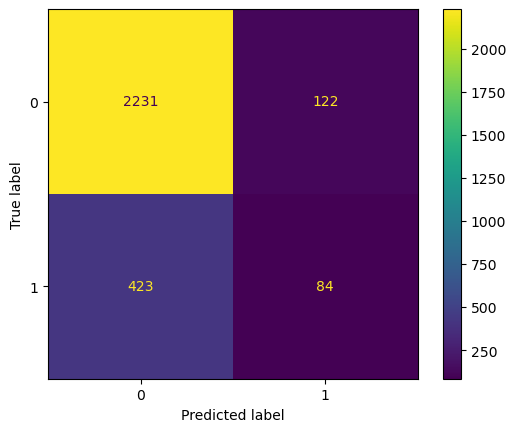

In [42]:
# Generate array of values for confusion matrix
cm = confusion_matrix(y_test, y_pred_test_xgb)

# Plot confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=xgb_cv.classes_)

disp.plot()

The model predicted three times as many false negatives than it did false positives, and it correctly identified only 16.6% of the users who actually churned.

### **Task 14. Feature importance**

Next we will inspect the most important features of the final model.

<Axes: title={'center': 'Feature importance'}, xlabel='F score', ylabel='Features'>

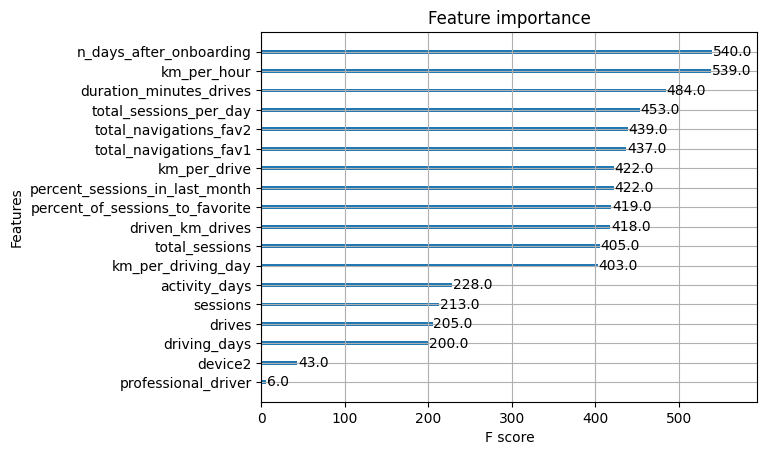

In [69]:
plot_importance(xgb_cv.best_estimator_)

The XGBoost model made use of many of the features.

This underscores the importance of feature engineering. Engineered features accounted for six of the top 10 features (and three of the top five). Feature engineering is often one of the best and easiest ways to boost model performance.

### **Task 15. Conclusions**

1) The model is somewhat useful for churn prediction, but not very. In using it we would be able to improve retention, but only slightly. As we identified little downside to not identifying churn (false negatives), then even a modestly predictive model is helpful. 

2) By splitting the data into training, validation, and test sets as opposed to just training and test sets we potentially reduce the performance of models slighty as we have less training data, but we increase the chance of generalizability of the model. 

3) The benefits of tree-based models like random forest of XGBoost over a logistic regression are that the models can have greater predictive ability (better performance) and better generalizablity, without excessively increasing overfitting. 

4) To improve the model we could continue to tune hyperparameters, but this seemed to have diminishing returns. You could train it with more data. And you could add features with a higher likelihood of predicting churn. 

5) For further improvements, tt would probably be useful to have information on car make, model, use location, traffic conditions, etc. 